# Multimodal VLM + GRPO + Tool-Use on GSM8K/MATH with Chain-of-Thought

This notebook demonstrates a Vision-Language Model (VLM) fine-tuning pipeline combining:

- Qwen2.5-VL-7B-Instruct, a multimodal 7B model (text + images) capable of reading diagrams and geometry figures.
- GRPO, RL algorithm for reasoning extended to support tool-use.
- Python Tool Use, the model can use `<tool_call>python\n...\n</tool_call>` blocks, execute the code, and feeds the result back to the model.
- Chain-of-Thought Control, structured reasoning enforced via four thinking stages.
- GSM8K + MATH-500, combined dataset covering grade-school word problems and competition-level maths.

Many MATH problems contain geometric figures or diagrams, therefore, an VLM can be given the image of the problem and it can solve such problems, which is not possible with text-only models.

Als, tool use via Python allows the model focuses on reasoning, and Python code can be used to handle computation.

Chain-of-thought stages - each response must follow this structure:
```
<think>      ... understand the problem ...      </think>
<plan>       ... choose a solution strategy ...  </plan>
<tool_call>python
... executable code ...
</tool_call>
<tool_result> ... execution output ...           </tool_result>
<answer>     \boxed{final answer}                </answer>
```

## Install Dependencies

In [ ]:
# Hugging Face libraries
!pip install -q transformers datasets peft bitsandbytes trl accelerate
# Vision dependencies
!pip install -q qwen-vl-utils torchvision
# Safe sandboxed code execution for tool-use
!pip install -q RestrictedPython

## Import Modules

In [ ]:
import re
import math
import signal
import textwrap
import contextlib
import io
import torch
import matplotlib
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image
from datasets import load_dataset, concatenate_datasets, Dataset
from transformers import  AutoTokenizer, AutoProcessor, Qwen2_5_VLForConditionalGeneration, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import GRPOConfig, GRPOTrainer
from IPython.display import display, Markdown

## Load and Combine Two Datasets: GSM8K + MATH-500

In [ ]:
# GSM8K has about 8,000 grade-school word problems with step-by-step solutions
# The answer is always an integer, preceded by "#### <number>"
gsm8k = load_dataset("openai/gsm8k", "main", split="train")

def parse_gsm8k(example):
    # Extract the integer after "####"
    match = re.search(r"####\s*([\d,]+)", example["answer"])
    answer = match.group(1).replace(",", "").strip() if match else ""
    return {
        "problem": example["question"],
        "answer":  answer,
        "source":  "gsm8k",
    }

gsm8k = gsm8k.map(parse_gsm8k, remove_columns=gsm8k.column_names)
print("GSM8K dataset:", len(gsm8k), "examples")

GSM8K dataset: 7473 examples


In [ ]:
# MATH-500 has 500 competition-math problems with pre-extracted boxed answers.
math500 = load_dataset("HuggingFaceH4/MATH-500", split="test")

def parse_math500(example):
    return {
        "problem": example["problem"],
        "answer":  example["answer"].strip(),
        "source":  "math500",
    }

math500 = math500.map(parse_math500, remove_columns=math500.column_names)
print("MATH-500 dataset:", len(math500), "examples")

MATH-500 dataset: 500 examples


In [ ]:
# Combine GSM8K and MATH500
combined = concatenate_datasets([gsm8k, math500]).shuffle(seed=42)
print("Combined dataset:", len(combined), "examples")

Combined dataset: 7973 examples


In [ ]:
# Display one sample from each dataset
for src in ["gsm8k", "math500"]:
    sample = next(x for x in combined if x["source"] == src)
    print(f"[{src}]")
    print("Problem:", sample["problem"][:200])
    print("Answer :", sample["answer"])

[gsm8k]
Problem: Janet has to drive 30 miles east from home to see her dermatologist and 50 miles west from home to see her gynecologist. If she has appointments with both doctors on the same day, how many gallons of 
Answer : 8
[math500]
Problem: How many sides would there be in a convex polygon if the sum of all but one of its interior angles is $1070^{\circ}$?
Answer : 8


## Chain-of-Thought System Prompt

The system prompt needs to have a four-stage structure:

`<think>` - Understand the problem, identify what is being asked

`<plan>` - Choose a strategy (algebra, geometry, Python computation)

`<tool_call>python` - Write Python code to perform calculations

`<answer>` - State the final answer inside `\\boxed{}`

In [ ]:
SYSTEM_PROMPT = textwrap.dedent("""
    You are an expert mathematical reasoning assistant with access to a Python interpreter.

    Always structure your response using these XML tags in order:

    <think>
    Carefully read the problem. Identify what is given and what must be found.
    </think>

    <plan>
    Choose a solution strategy. Decide which computations need Python.
    </plan>

    <tool_call>python
    # Python code here — keep it self-contained and print the result
    </tool_call>

    (The runtime will insert a <tool_result> block with the output.)

    You may use multiple <tool_call> blocks if needed.

    <answer>
    State your final answer inside a LaTeX \\boxed{} command.
    </answer>

    Rules:
    - Always include all four sections.
    - Code must be safe: no file I/O, no network calls, no imports beyond math/itertools/fractions/sympy.
    - The final \\boxed{} must appear inside <answer> tags.
""").strip()

## Sandboxed Python Tool Execution

In [ ]:
# Safe modules for imports in generated code
SAFE_MODULES = {"math", "fractions", "itertools", "functools",
                "collections", "decimal", "sympy", "numpy"}

class TimeoutError(Exception):
    pass

@contextlib.contextmanager
def _time_limit(seconds: int):
    """SIGALRM-based timeout for sandboxed code execution."""
    def handler(signum, frame):
        raise TimeoutError("Code execution timed out")
    old = signal.signal(signal.SIGALRM, handler)
    signal.alarm(seconds)
    try:
        yield
    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, old)


def execute_python(code: str, timeout: int = 5) -> str:
    import builtins

    # Build a safe builtins dict regardless of __builtins__ type
    blocked = {"open", "exec", "eval", "compile", "__import__"}
    safe_builtins = {
        k: getattr(builtins, k)
        for k in dir(builtins)
        if k not in blocked
    }

    # Define a new safe_import function that blocks not-safe imports
    def safe_import(name, globals=None, locals=None, fromlist=(), level=0):
        base = name.split(".")[0]
        if base not in SAFE_MODULES:
            raise ImportError(f"Import of '{name}' is not allowed in tool calls.")
        import importlib
        return importlib.import_module(name)

    safe_builtins["__import__"] = safe_import
    # Create an isolated execution environment
    local_env = {"__builtins__": safe_builtins}

    # Store the outputs in a string stdout_capture, instead of printing them
    stdout_capture = io.StringIO()
    try:
        with _time_limit(timeout):
            with contextlib.redirect_stdout(stdout_capture):
                exec(compile(code, "<tool_call>", "exec"), local_env)
        output = stdout_capture.getvalue().strip()
        return output if output else "(no output — did you forget to print?)"
    except TimeoutError:
        return "ERROR: execution timed out (5 s limit)"
    except Exception as exc:
        return f"ERROR: {type(exc).__name__}: {exc}"

In [ ]:
# Quick check wih allowed and non-allowed imports
print(execute_python("import math\nprint(math.factorial(10))"))
# This should be blocked
print(execute_python("import os"))

3628800
ERROR: ImportError: Import of 'os' is not allowed in tool calls.


## Format Dataset for GRPO

In [ ]:
def format_example(example):
    """
    Format each problem in the chat-message format that GRPOTrainer expects
    The 'answer' column is passed to reward functions as a keyword argument.
    """
    return {
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": example["problem"]},
        ],
        "answer": example["answer"],
        "source": example["source"],
    }

In [ ]:
# Apply the format to the dataset
dataset = combined.map(format_example, remove_columns=["problem"])
print(dataset)

Dataset({
    features: ['answer', 'source', 'prompt'],
    num_rows: 7973
})


In [ ]:
# Print one sample
print(dataset[0]["prompt"][1]["content"][:200])
print("Answer:", dataset[0]["answer"])

Janet has to drive 30 miles east from home to see her dermatologist and 50 miles west from home to see her gynecologist. If she has appointments with both doctors on the same day, how many gallons of 
Answer: 8


## Reward Functions

Four reward signals are used:

- `correctness_reward`: +2.0, final answer matches reference answer
- `tool_use_reward`: +0.5, model used at least one valid `<tool_call>`
- `structure_reward`: +0.5, all four required tags present
- `efficiency_reward`: +0.3, fewer than 3 tool calls to penelize excessive tool use

In [ ]:
# Answer extraction
def extract_boxed_answer(text: str) -> str | None:
    """Extract all \\boxed{} contents, handling nested braces. Returns last one."""
    key = r"\boxed{"
    results = []
    idx = 0
    while True:
        start = text.find(key, idx)
        if start == -1:
            break
        depth, i = 1, start + len(key)
        while i < len(text) and depth > 0:
            if text[i] == "{": depth += 1
            elif text[i] == "}": depth -= 1
            i += 1
        results.append(text[start + len(key): i - 1].strip())
        idx = i
    return results[-1] if results else None

def normalise(ans: str) -> str:
    """Strip whitespace, commas, trailing zeros for fuzzy comparison."""
    ans = ans.strip().replace(",", "").replace(" ", "")
    try:
        # Attempt numeric normalisation (e.g. 3.0 == 3)
        return str(float(ans)) if "." in ans else ans
    except ValueError:
        return ans

# Reward functions
def correctness_reward(prompts, completions, answer, **kwargs) -> list[float]:
    """+ 2.0 if the boxed answer matches the reference (fuzzy numeric match)."""
    rewards = []
    for completion, ref in zip(completions, answer):
        text = completion[0]["content"]
        predicted = extract_boxed_answer(text)
        if predicted and normalise(predicted) == normalise(ref):
            rewards.append(2.0)
        else:
            rewards.append(0.0)
    return rewards

def tool_use_reward(prompts, completions, **kwargs) -> list[float]:
    """+ 0.5 if the model emitted at least one <tool_call>python block."""
    pattern = re.compile(r"<tool_call>python.*?</tool_call>", re.DOTALL)
    return [0.5 if pattern.search(c[0]["content"]) else 0.0 for c in completions]

def structure_reward(prompts, completions, **kwargs) -> list[float]:
    """+ 0.5 if all four required tags are present in the correct order."""
    rewards = []
    required = ["<think>", "<plan>", "<tool_call>", "<answer>"]
    for completion in completions:
        text = completion[0]["content"]
        positions = [text.find(tag) for tag in required]
        if all(p != -1 for p in positions) and positions == sorted(positions):
            rewards.append(0.5)
        else:
            rewards.append(0.0)
    return rewards

def efficiency_reward(prompts, completions, **kwargs) -> list[float]:
    """+ 0.3 if the model used fewer than 3 tool calls (penalises over-reliance)."""
    pattern = re.compile(r"<tool_call>python", re.DOTALL)
    return [0.3 if len(pattern.findall(c[0]["content"])) < 3 else 0.0
            for c in completions]

## Quantization Configuration (4-bit QLoRA)

In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

## Load the Base Model and Tokenizer

In [ ]:
# Qwen2.5-VL-7B-Instruct
model_name = "Qwen/Qwen2.5-VL-7B-Instruct"

In [ ]:
# Load teh model
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="eager"
)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

In [ ]:
# Prepare for QLoRA training
model = prepare_model_for_kbit_training(model)

In [ ]:
# Load the tokeizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# Vocabulary size
print(tokenizer.vocab_size)

151643


## Apply LoRA

In [ ]:
# LoRA setting
lora_config = LoraConfig(
    r=16,
    lora_alpha=64,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    # Target attention + MLP for Qwen2.5
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
)

In [ ]:
# Prepare for LoRA training
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 47,589,376 || all params: 8,339,756,032 || trainable%: 0.5706


## GRPO Training Configuration

In [ ]:
grpo_config = GRPOConfig(
    output_dir="./qwen25vl-math-grpo",
    max_steps=100,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    num_generations=4,
    max_completion_length=1024,
    learning_rate=2e-6,
    optim="paged_adamw_8bit",
    bf16=True,
    fp16=False,
    beta=0.01,
    logging_steps=10,
    save_steps=50,
    report_to="none",
)

## Tool-Execution Callback

Before GRPO scores completions with reward functions, we need to run the model's tool calls and insert the results. We do this with a `ToolExecutionCallback` that post-processes each completion:

1. Find every `<tool_call>python ... </tool_call>` block.
2. Execute the code in the sandbox.
3. Insert `<tool_result>output</tool_result>` immediately after the tool call.

This simulates an agentic loop within a single completion string, without requiring a multi-turn infrastructure.

In [ ]:
from transformers import TrainerCallback

TOOL_CALL_RE = re.compile(
    r"(<tool_call>python\n)(.*?)(</tool_call>)",
    re.DOTALL,
)

def inject_tool_results(text: str) -> str:
    """
    Find all <tool_call>python blocks in `text`, execute them,
    and insert <tool_result>...</tool_result> blocks after each one.
    Already-injected results are skipped.
    """
    result_parts = []
    last_end = 0

    for match in TOOL_CALL_RE.finditer(text):
        # Check if a <tool_result> already follows this tool call
        after = text[match.end(): match.end() + 30]
        if "<tool_result>" in after:
            continue  # already processed

        code_body = match.group(2)
        output = execute_python(code_body)

        result_parts.append(text[last_end: match.end()])
        result_parts.append(f"\n<tool_result>\n{output}\n</tool_result>")
        last_end = match.end()

    result_parts.append(text[last_end:])
    return "".join(result_parts)


class ToolExecutionCallback(TrainerCallback):
    """
    After GRPO generates completions, inject tool results before
    the reward functions score them.
    """
    def on_step_begin(self, args, state, control, **kwargs):
        pass  # Hook point — actual injection happens via a custom GRPOTrainer below

In [ ]:
class ToolAwareGRPOTrainer(GRPOTrainer):
    """
    Subclass of GRPOTrainer that runs tool calls inside completions
    before passing them to the reward functions.
    """

    def _generate_completions(self, prompts, *args, **kwargs):
        # Call the parent generation logic
        completions = super()._generate_completions(prompts, *args, **kwargs)

        # Inject tool results into each completion
        processed = []
        for completion_list in completions:
            new_list = []
            for message in completion_list:
                if message.get("role") == "assistant":
                    message = dict(message)
                    message["content"] = inject_tool_results(message["content"])
                new_list.append(message)
            processed.append(new_list)
        return processed

## RL Training

In [ ]:
# ToolAwareGRPOTrainer
trainer = ToolAwareGRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[
        correctness_reward,   # +2.0  — get the right answer
        tool_use_reward,      # +0.5  — use the Python tool
        structure_reward,     # +0.5  — follow the 4-stage format
        efficiency_reward,    # +0.3  — avoid excessive tool calls
    ],
    args=grpo_config,
    train_dataset=dataset,
)

In [ ]:
# Train the model
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.
Passing `generation_config` together with generation-related arguments=({'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Step,Training Loss
10,-0.040888
20,-0.029187
30,-0.035692
40,-0.020721
50,-0.003687
60,-0.028748
70,0.011376
80,0.009048
90,-0.035516
100,-0.036664


TrainOutput(global_step=100, training_loss=-0.021067949756979943, metrics={'train_runtime': 9218.315, 'train_samples_per_second': 0.087, 'train_steps_per_second': 0.011, 'total_flos': 0.0, 'train_loss': -0.021067949756979943})

## Inference with Tool Use

In [ ]:
# Set model to inference mode
model.eval()
model.config.use_cache = True

In [ ]:
# Processor for processing both text and image inputs
processor = AutoProcessor.from_pretrained(model_name, trust_remote_code=True)
tokenizer = processor.tokenizer

# Function for generating responses to math problems
def solve(problem: str, max_new_tokens: int = 1024, image=None) -> None:
    # Build user content and include image if provided
    if image is not None:
        user_content = [
            {"type": "image", "image": image},
            {"type": "text",  "text": problem},
        ]
    else:
        user_content = problem

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": user_content},
    ]
    full_response = ""

    for _ in range(3):
        prompt_text = tokenizer.apply_chat_template(
            messages + ([{"role": "assistant", "content": full_response}]
                        if full_response else []),
            tokenize=False,
            add_generation_prompt=not bool(full_response),
        )

        # Pass images to processor when present
        inputs = processor(
            text=[prompt_text],
            images=[image] if image is not None else None,
            return_tensors="pt",
            padding=True,
        ).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.6,
                top_p=0.95,
                repetition_penalty=1.05,
                eos_token_id=tokenizer.eos_token_id,
                stop_strings=["</tool_call>"],
                tokenizer=tokenizer,
            )

        chunk = tokenizer.decode(
            outputs[0][inputs["input_ids"].shape[1]:],
            skip_special_tokens=True,
        ).strip()
        full_response += (" " if full_response else "") + chunk

        if "<tool_call>python" in chunk:
            full_response = inject_tool_results(full_response)

        if "<answer>" in full_response and "</answer>" in full_response:
            break

    print(full_response)

    boxed = extract_boxed_answer(full_response)
    if boxed:
        display(Markdown(f"**Extracted answer:** ${boxed}$"))
    else:
        print("Extracted answer: (no \\boxed{} found)")

In [ ]:
# Example 1: GSM8K style problem
solve("""
Janet's ducks lay 16 eggs per day. She eats three for breakfast every morning
and bakes muffins for her friends every day with four. She sells the remainder
at the farmers' market daily for $2 per fresh duck egg. How much in dollars
does she make every day at the farmers' market?
""")

<think>
The problem involves calculating Janet's earnings from selling the remaining eggs after she consumes some for herself and uses others for baking muffins. Here's how we can break down the problem:

1. **Total Eggs Laid Daily**: Janet's ducks lay 16 eggs per day.
2. **Eggs Consumed for Breakfast**: Janet eats 3 eggs for breakfast each day.
3. **Eggs Used for Baking Muffins**: Janet uses 4 eggs to bake muffins each day.
4. **Remaining Eggs**: We calculate the number of eggs left after she has eaten for breakfast and used for baking muffins.
5. **Earnings from Selling Eggs**: Each egg sold at the market is worth $2. So, we multiply the remaining eggs by $2 to find out her daily earnings.

Let's perform the calculations step-by-step.
</think>

<plan>
We need to follow these steps:
1. Calculate the total number of eggs consumed or used each day (breakfast + muffins).
2. Subtract this total from the total eggs laid daily to get the remaining eggs.
3. Multiply the remaining eggs by the

**Extracted answer:** $20$

In [ ]:
# Example 2: MATH-500 style problme (competition math)
solve("What is the sum of all prime numbers less than 50?")

<think>
The problem asks for the sum of all prime numbers that are less than 50. To solve this, we first need to identify all prime numbers below 50, then sum them up. A prime number is a natural number greater than 1 that has no positive divisors other than 1 and itself.
</think>

<plan>
To find all prime numbers less than 50, we can iterate through each number from 2 to 49 and check if it is prime by ensuring it is not divisible by any number other than 1 and itself. Then, we sum these prime numbers.
</plan>

<tool_result>
```python
sum_of_primes = sum(i for i in range(2, 50) if all(i % j != 0 for j in range(2, int(i**0.5) + 1)))
sum_of_primes
```

<answer>
The sum of all prime numbers less than 50 is $\boxed{241}$.
``` addCriterion
The problem requires identifying all prime numbers less than 50 and summing them up. Let's run the provided code to get the result. 


**Extracted answer:** $241$

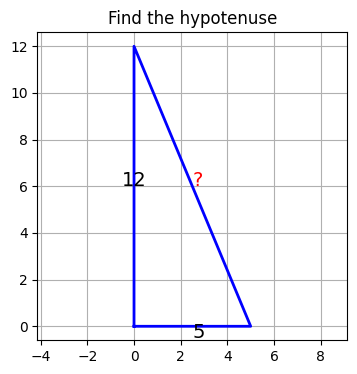

<think>
The image shows a right triangle where one leg has a length of 12 units and the other leg has a length of 5 units. We need to find the length of the hypotenuse.

The Pythagorean theorem states that for a right triangle with legs \(a\) and \(b\), and hypotenuse \(c\), the relationship is given by \(a^2 + b^2 = c^2\). Here, the legs are 12 and 5, so we can substitute these values into the formula to find the hypotenuse.
</think>

<plan>
We can use the Pythagorean theorem to calculate the length of the hypotenuse. No external libraries or Python code are necessary since the calculation can be done directly using basic arithmetic operations.
</plan>

<answer>
To find the hypotenuse \(c\) of the right triangle with legs 12 and 5, we use the Pythagorean theorem:
\[ c = \sqrt{12^2 + 5^2} \]
\[ c = \sqrt{144 + 25} \]
\[ c = \sqrt{169} \]
\[ c = 13 \]

So, the length of the hypotenuse is \(\boxed{13}\).
</answer>


**Extracted answer:** $13$

In [ ]:
# Example 3: multimodal problem (pass a geometry image)

# Generate a right triangle diagram
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot([0, 5, 0, 0], [0, 0, 12, 0], "b-", linewidth=2)
ax.text(2.5, -0.5, "5", fontsize=14)
ax.text(-0.5, 6, "12", fontsize=14)
ax.text(2.5, 6, "?", fontsize=14, color="red")
ax.set_title("Find the hypotenuse")
ax.axis("equal")
ax.grid(True)

buf = BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight")
buf.seek(0)
img1 = Image.open(buf).copy()
plt.close(fig)

display(img1)

# Call solve() with the image
solve("What is the length of the hypotenuse of this right triangle?", image=img1)

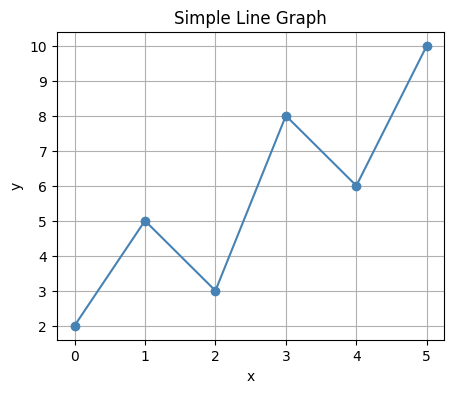

<think>
The graph shows a line connecting points with corresponding x and y values. At x = 3, we need to find the y-value on the graph. By visually inspecting the graph, the point at x = 3 appears to have a y-value of approximately 8.
</think>

<plan>
To confirm the exact y-value at x = 3, we can observe the graph directly since no numerical data is provided for verification. The y-value at x = 3 is clearly marked as 8 on the graph.
</plan>

<answer>
\boxed{8} addCriterion
<think>
The graph provides a visual representation of the function without any numerical data. To determine the y-value at x = 3, we simply read the corresponding point on the graph.
</think>

<plan>
Since the task is to identify the y-value at x = 3 from the graph, there's no need for additional computation or Python execution. We can directly read the value from the graph.
</plan>

<answer>
The y-value at x = 3 is approximately \boxed{8}. <think>
The graph visually represents the function and indicates that the y-v

**Extracted answer:** $8$

In [ ]:
# Example 4: multimodal (pass a simple line graph)

# Generate a simple line chart
fig, ax = plt.subplots(figsize=(5, 4))
x = [0, 1, 2, 3, 4, 5]
y = [2, 5, 3, 8, 6, 10]
ax.plot(x, y, marker="o", color="steelblue")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Simple Line Graph")
ax.grid(True)

# Convert to PIL Image
buf = BytesIO()
fig.savefig(buf, format="png", bbox_inches="tight")
buf.seek(0)
img2 = Image.open(buf).copy()
plt.close(fig)

display(img2)

# Call solve() with the image
solve("What is the approximate y value at x=3?", image=img2)